# Acompanhamento 1 - Analise Exploratoria

Projeto de competicao de Machine Learning para previsao de precos de imoveis em Ames, Iowa.

Este notebook cobre somente o que foi pedido no **Acompanhamento 1**: analise exploratoria a partir do dataset ja limpo e entendimento dos dados para orientar as proximas etapas. Execute primeiro o notebook `acomp_1_estrategia_limpeza.ipynb`, que gera os arquivos em `data/processed/`.

A modelagem, o `pipeline.py` e os resultados preliminares de modelos ficam fora deste notebook porque pertencem ao acompanhamento 2.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists() and (candidate / 'docs').exists():
            return candidate
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto com as pastas data/ e docs/.')

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
TRAIN_PATH = DATA_DIR / 'treino.csv'
TEST_PATH = DATA_DIR / 'teste_publico.csv'
CLEAN_TRAIN_PATH = PROCESSED_DIR / 'treino_limpo.csv'
CLEAN_TEST_PATH = PROCESSED_DIR / 'teste_publico_limpo.csv'
RANDOM_STATE = 42


In [2]:
if not CLEAN_TRAIN_PATH.exists() or not CLEAN_TEST_PATH.exists():
    raise FileNotFoundError(
        'Datasets limpos nao encontrados. Execute primeiro o notebook '
        'acomp_1_estrategia_limpeza.ipynb para gerar data/processed/treino_limpo.csv '
        'e data/processed/teste_publico_limpo.csv.'
    )

treino = pd.read_csv(CLEAN_TRAIN_PATH)
teste_publico = pd.read_csv(CLEAN_TEST_PATH)

print(f'Raiz do projeto: {PROJECT_ROOT}')
print(f'Treino limpo: {treino.shape[0]} linhas x {treino.shape[1]} colunas')
print(f'Teste publico limpo: {teste_publico.shape[0]} linhas x {teste_publico.shape[1]} colunas')
print('Colunas presentes no treino e ausentes no teste:', sorted(set(treino.columns) - set(teste_publico.columns)))
print('Colunas presentes no teste e ausentes no treino:', sorted(set(teste_publico.columns) - set(treino.columns)))

treino.head()

Raiz do projeto: /home/arthur/dev/unifor/ciência de dados
Treino limpo: 1168 linhas x 81 colunas
Teste publico limpo: 1459 linhas x 80 colunas
Colunas presentes no treino e ausentes no teste: ['SalePrice']
Colunas presentes no teste e ausentes no treino: []


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,Ausente,Reg,Lvl,AllPub,...,0,Ausente,Ausente,Ausente,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,Ausente,IR1,Lvl,AllPub,...,0,Ausente,Ausente,Ausente,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,Ausente,Reg,Lvl,AllPub,...,0,Ausente,MnPrv,Ausente,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,Ausente,Reg,Lvl,AllPub,...,0,Ausente,MnPrv,Ausente,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,Ausente,Ausente,Ausente,0,5,2010,WD,Normal,127000


## Leitura inicial

A EDA consome os datasets limpos produzidos pelo notebook de limpeza: `data/processed/treino_limpo.csv` e `data/processed/teste_publico_limpo.csv`. A base de treino limpa possui a variavel alvo `SalePrice`; a base publica de teste limpa possui as mesmas variaveis explicativas, sem o alvo.

In [3]:
info_df = pd.DataFrame({
    'dtype': treino.dtypes.astype(str),
    'nulos': treino.isna().sum(),
    'nulos_pct': (treino.isna().mean() * 100).round(2),
    'valores_unicos': treino.nunique(dropna=False),
})
info_df.sort_values(['nulos_pct', 'valores_unicos'], ascending=[False, False]).head(25)

,dtype,nulos,nulos_pct,valores_unicos
Id,int64,0,0.0,1168
LotArea,int64,0,0.0,890
GrLivArea,int64,0,0.0,734
BsmtUnfSF,int64,0,0.0,685
1stFlrSF,int64,0,0.0,657
TotalBsmtSF,int64,0,0.0,630
SalePrice,int64,0,0.0,571
BsmtFinSF1,int64,0,0.0,549
GarageArea,int64,0,0.0,394
2ndFlrSF,int64,0,0.0,361


## Distribuicao do alvo

Como a metrica final do projeto e RMSLE, interessa observar a distribuicao de `SalePrice` em escala original e em escala logaritmica. A escala log tende a reduzir a assimetria e combina com a orientacao do PDF de trabalhar com `np.log1p(SalePrice)` em etapas futuras de modelagem.

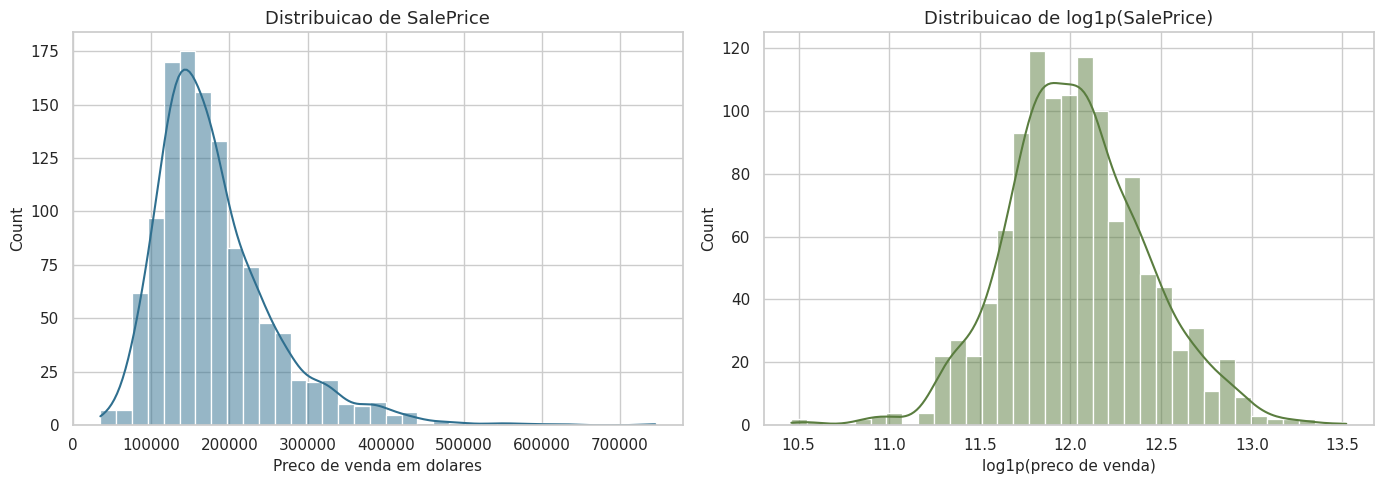

,count,mean,std,min,25%,50%,75%,max
SalePrice,1168.0,181441.541952,77263.583862,34900.0,130000.0,165000.0,214925.0,745000.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(treino['SalePrice'], kde=True, bins=35, ax=axes[0], color='#2f6f8f')
axes[0].set_title('Distribuicao de SalePrice')
axes[0].set_xlabel('Preco de venda em dolares')

sns.histplot(np.log1p(treino['SalePrice']), kde=True, bins=35, ax=axes[1], color='#5a7d3f')
axes[1].set_title('Distribuicao de log1p(SalePrice)')
axes[1].set_xlabel('log1p(preco de venda)')

plt.tight_layout()
plt.show()

treino['SalePrice'].describe().to_frame().T

In [5]:
resumo_preco = treino['SalePrice'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).to_frame('SalePrice')
resumo_preco.loc[['mean', 'median', 'std', 'min', 'max']] = resumo_preco.loc[['mean', 'median', 'std', 'min', 'max']].round(2)
resumo_preco

,SalePrice
count,1168.00
mean,181441.54
median,165000.00
std,77263.58
min,34900.00
max,745000.00


## Dados faltantes apos a limpeza

Como a entrada deste notebook ja e o dataset limpo, o esperado e que nao existam nulos restantes. A analise dos nulos originais e das regras de imputacao fica documentada no notebook de estrategia de limpeza.

In [6]:
def missing_table(df):
    out = pd.DataFrame({
        'nulos': df.isna().sum(),
        'nulos_pct': (df.isna().mean() * 100).round(2),
    })
    return out[out['nulos'] > 0].sort_values('nulos_pct', ascending=False)

missing_train = missing_table(treino)
missing_test = missing_table(teste_publico)

if missing_train.empty:
    print('Nao ha valores faltantes no treino limpo.')
else:
    display(missing_train.head(25))

Nao ha valores faltantes no treino limpo.


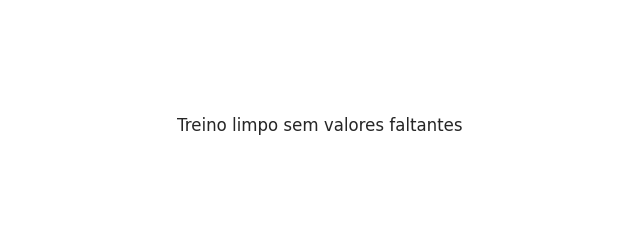

In [ ]:
if missing_train.empty:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.text(0.5, 0.5, 'Treino limpo sem valores faltantes', ha='center', va='center', fontsize=12)
    ax.set_axis_off()
    plt.show()
else:
    plot_missing = missing_train.head(20).sort_values('nulos_pct')
    ax = plot_missing['nulos_pct'].plot(kind='barh', color='#9a6b35', figsize=(10, 7))
    ax.set_title('Top 20 colunas com dados faltantes no treino limpo')
    ax.set_xlabel('% de valores faltantes')
    ax.set_ylabel('')
    plt.tightf_layout()
    plt.show()

In [8]:
missing_compare = missing_train.rename(columns={'nulos': 'nulos_treino', 'nulos_pct': 'pct_treino'}).join(
    missing_test.rename(columns={'nulos': 'nulos_teste', 'nulos_pct': 'pct_teste'}), how='outer'
).fillna(0)

if missing_compare.empty:
    print('Nao ha valores faltantes nos datasets limpos de treino e teste publico.')
else:
    display(missing_compare.sort_values('pct_treino', ascending=False).head(25))

Nao ha valores faltantes nos datasets limpos de treino e teste publico.


## Correlacoes numericas com o preco

As variaveis numericas mais associadas ao preco sao indicadores de qualidade, area construida, garagem, porao, banheiros e idade/reforma. Essas variaveis devem receber tratamento cuidadoso de nulos e outliers.

,corr_SalePrice
OverallQual,0.785555
GrLivArea,0.695652
GarageCars,0.640991
GarageArea,0.624139
TotalBsmtSF,0.597766
1stFlrSF,0.587883
FullBath,0.552546
TotRmsAbvGrd,0.520388
YearBuilt,0.516501
YearRemodAdd,0.508593


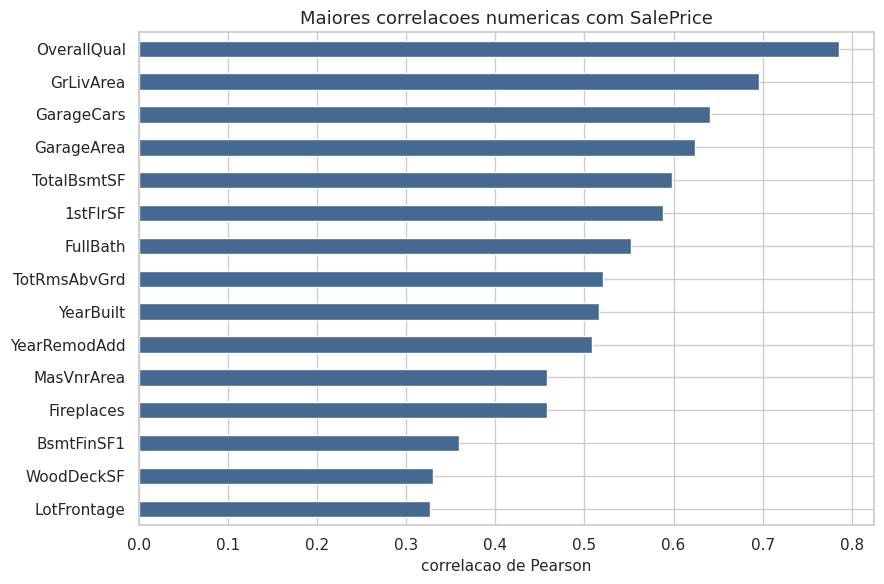

In [ ]:
numeric_cols = treino.select_dtypes(include=np.number).columns.drop(['SalePrice'])
correlations = treino[numeric_cols.tolist() + ['SalePrice']].corr(numeric_only=True)['SalePrice'].drop('SalePrice')
top_corr = correlations.reindex(correlations.abs().sort_values(ascending=False).index).head(15)

display(top_corr.to_frame('corr_SalePrice'))

ax = top_corr.sort_values().plot(kind='barh', color='#456990', figsize=(9, 6))
ax.set_title('Maiores correlacoes numericas com SalePrice')
ax.set_xlabel('correlacao de Pearson')
ax.set_ylabel('')f
plt.tight_layout()
plt.show()

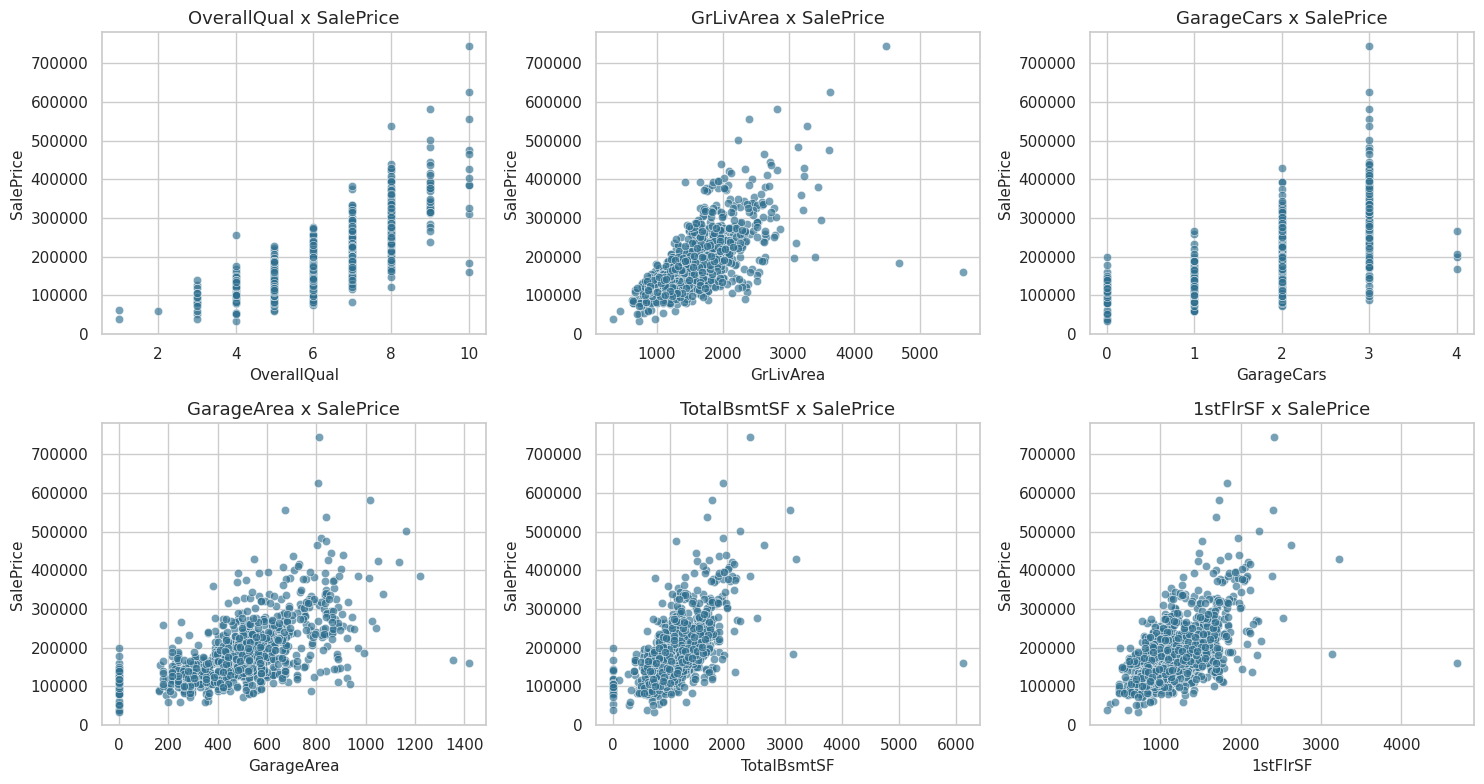

In [10]:
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), features):
    sns.scatterplot(data=treino, x=col, y='SalePrice', alpha=0.65, ax=ax, color='#2f6f8f')
    ax.set_title(f'{col} x SalePrice')
plt.tight_layout()
plt.show()

## Variaveis categoricas

`Neighborhood` e uma das variaveis categoricas mais importantes para o negocio, pois representa localizacao. No acompanhamento 2, ela deve ser codificada no pipeline com cuidado para evitar categorias desconhecidas no teste.

In [ ]:
categorical_cols = treino.select_dtypes(exclude=np.number).columns
cardinalidade = treino[categorical_cols].nunique(dropna=False).sort_values(ascending=False).to_frame('valores_unicos')
cardinalidade.head(20)

,valores_unicos
Neighborhood,25
Exterior2nd,16
Exterior1st,15
Condition1,9
SaleType,9
HouseStyle,8
Condition2,8
RoofMatl,7
GarageType,7
BsmtFinType2,7


,count,median,mean
Neighborhood,,,
NridgHt,61,314813.0,312157.098361
NoRidge,33,290000.0,323185.090909
StoneBr,20,282000.0,302605.700000
Veenker,9,245500.0,251944.444444
Somerst,69,226700.0,226403.797101
Timber,28,226250.0,236141.535714
ClearCr,19,211000.0,221842.105263
Crawfor,44,208550.0,211587.204545
CollgCr,115,200500.0,201112.008696


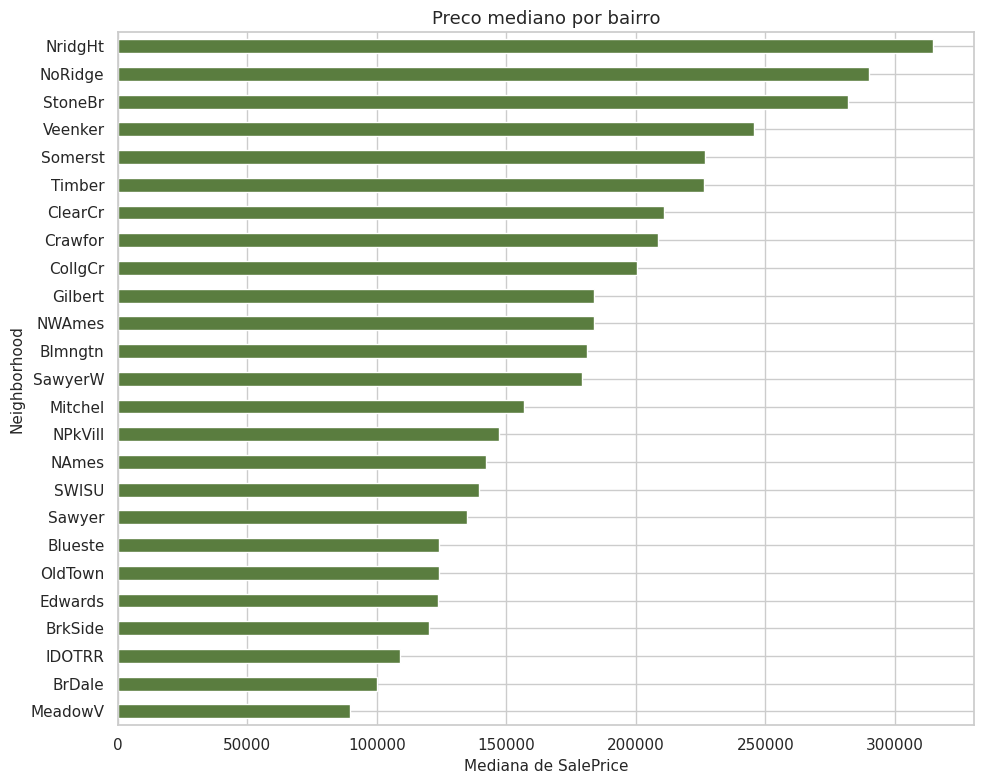

In [12]:
neighborhood_prices = treino.groupby('Neighborhood')['SalePrice'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False)
display(neighborhood_prices.head(12))

ax = neighborhood_prices['median'].sort_values().plot(kind='barh', figsize=(10, 8), color='#5a7d3f')
ax.set_title('Preco mediano por bairro')
ax.set_xlabel('Mediana de SalePrice')
ax.set_ylabel('Neighborhood')
plt.tight_layout()
plt.show()

## Outliers iniciais

A deteccao abaixo usa a regra do IQR para sinalizar pontos extremos. A decisao final nao deve ser apagar automaticamente: alguns pontos podem representar imoveis raros, mas validos. Para o acompanhamento 1, eles ficam marcados como candidatos a tratamento por winsorizacao, transformacao log ou revisao manual.

In [13]:
outlier_cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea', '1stFlrSF']
outlier_rows = []
for col in outlier_cols:
    q1, q3 = treino[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (treino[col] < lower) | (treino[col] > upper)
    outlier_rows.append({
        'variavel': col,
        'limite_inferior': round(lower, 2),
        'limite_superior': round(upper, 2),
        'qtd_outliers': int(mask.sum()),
        'pct_outliers': round(mask.mean() * 100, 2),
    })

pd.DataFrame(outlier_rows).sort_values('qtd_outliers', ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,pct_outliers
4,LotArea,1418.12,17869.12,54,4.62
0,SalePrice,2612.50,342312.50,48,4.11
2,TotalBsmtSF,41.12,2054.12,47,4.02
1,GrLivArea,176.38,2761.38,23,1.97
3,GarageArea,-11.50,928.50,18,1.54
5,1stFlrSF,124.88,2159.88,13,1.11


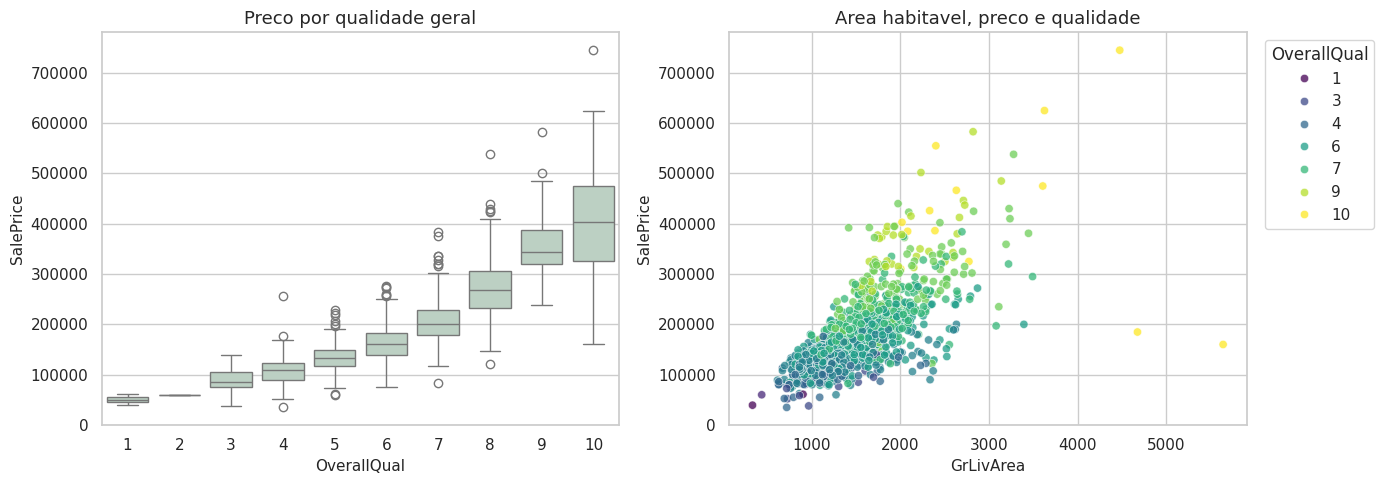

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=treino, x='OverallQual', y='SalePrice', ax=axes[0], color='#b9d3c2')
axes[0].set_title('Preco por qualidade geral')

sns.scatterplot(data=treino, x='GrLivArea', y='SalePrice', hue='OverallQual', palette='viridis', ax=axes[1], alpha=0.75)
axes[1].set_title('Area habitavel, preco e qualidade')
axes[1].legend(title='OverallQual', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Principais achados do Acompanhamento 1

- A EDA foi executada sobre o dataset limpo gerado pelo notebook `acomp_1_estrategia_limpeza.ipynb`.
- `SalePrice` e assimetrico a direita; usar `log1p` no alvo e consistente com a metrica RMSLE em etapas futuras.
- Os maiores sinais numericos de preco sao `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF` e `1stFlrSF`.
- O dataset limpo nao possui nulos restantes; as regras de imputacao preservam ausencias semanticas como `Ausente` ou `0`.
- `Neighborhood` continua sendo uma variavel categorica importante por representar localizacao.
- Existem outliers em preco, area do lote, area construida, porao e garagem; devem ser tratados com cautela para nao remover casas caras ou grandes que sejam validas.
- As colunas do teste publico limpo batem com as explicativas do treino limpo; a unica diferenca esperada e a ausencia de `SalePrice`.